In [ ]:
import os
import gc
import sys
import sklearn
import pathlib
import imblearn
import keras_tuner
import numpy as np
import collections
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from model import Resnet, ResnetTuner

sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("Modules"))))
import Modules.ds_loader as ds_loader

dataset_loader = ds_loader.DatasetLoader(
    xlsx_path="../Data/Internal_Dataset/Label_Map.xlsx",
    data_dir="../Data/Internal_Dataset",
)

X, y = dataset_loader.load_data()

X_train, X_temp, y_train, y_temp = sklearn.model_selection.train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

X_val, X_test, y_val, y_test = sklearn.model_selection.train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, shuffle=True
)
print(f"Class distribution of training: {collections.Counter(y_train)}")
print(f"Class distribution of validation: {collections.Counter(y_val)}")
print(f"Class distribution of test: {collections.Counter(y_test)}")
def min_max_normalize(*datasets):
    normalized_datasets = []
    for data in datasets:
        norm_data = []
        for sample in data:
            min_val = np.min(sample)
            max_val = np.max(sample)
            if max_val - min_val == 0:
                norm_sample = np.zeros_like(sample, dtype=np.float32)
            else:
                norm_sample = (sample - min_val) / (max_val - min_val)
            norm_data.append(norm_sample)
        normalized_datasets.append(np.stack(norm_data, axis=0).astype(np.float32))
    return normalized_datasets

INPUT_SIZE, FILTERS = 500, 64
RDIR = pathlib.Path(f"Results/RES_{INPUT_SIZE}_{FILTERS}_09")
MDIR = RDIR / f"RES_{INPUT_SIZE}_{FILTERS}.keras"
CDIR = RDIR / f"RES_{INPUT_SIZE}_{FILTERS}_CHECKPOINT"
CVDIR = RDIR / f"RES_{INPUT_SIZE}_CROSS_VAL"



Class distribution of training: Counter({np.int32(2): 3136, np.int32(1): 1803, np.int32(0): 1773, np.int32(3): 1758})
Class distribution of validation: Counter({np.int32(2): 563, np.int32(3): 350, np.int32(1): 342, np.int32(0): 333})
Class distribution of test: Counter({np.int32(2): 189, np.int32(1): 115, np.int32(3): 114, np.int32(0): 112})


In [12]:
tuner = keras_tuner.RandomSearch(
    ResnetTuner(),
    objective="val_loss",
    max_trials=100,
    overwrite=False,
    directory=RDIR,
    project_name=f"RES_{INPUT_SIZE}_{FILTERS}",
)

tuner.reload()

best_trials = tuner.oracle.get_best_trials(num_trials=30)

for trial in best_trials:
    val_loss = trial.metrics.get_last_value("val_loss")
    print(f"Trial ID: {trial.trial_id}, val_accuracy: {trial.score}, val_loss: {val_loss}")
    print("Hyperparameters:", trial.hyperparameters.values)


Reloading Tuner from Results/RES_500_64_09/RES_500_64/tuner0.json
Trial ID: 119, val_accuracy: 0.10949298739433289, val_loss: 0.10949298739433289
Hyperparameters: {'f_units': 32, 'p_size': 5, 'n_convolutions': 3, 'm_convolutions': 3, 'kernel_size_init': 3, 'kernel_size_res': 3, 'coefficient': 1, 'dense_units_1': 64, 'dropout_1': 0.3, 'dense_units_2': 64, 'dropout_2': 0.3, 'learning_rate': 0.005100109355686097, 'weight_decay': 0.004574004727815324, 'batch_size': 32}
Trial ID: 163, val_accuracy: 0.11351891607046127, val_loss: 0.11351891607046127
Hyperparameters: {'f_units': 32, 'p_size': 5, 'n_convolutions': 3, 'm_convolutions': 3, 'kernel_size_init': 3, 'kernel_size_res': 3, 'coefficient': 1, 'dense_units_1': 64, 'dropout_1': 0.35, 'dense_units_2': 64, 'dropout_2': 0.5, 'learning_rate': 0.0033870182724147825, 'weight_decay': 0.009308089454387202, 'batch_size': 32}
Trial ID: 124, val_accuracy: 0.1150164008140564, val_loss: 0.1150164008140564
Hyperparameters: {'f_units': 32, 'p_size': 5, 

In [13]:
best_trials = tuner.oracle.get_best_trials(num_trials=30)[26]
best_hps = best_trials.hyperparameters.values
print("Best Model Hyperparameter:")
for key, value in best_hps.items():
    print(f"{key}: {value}")


Best Model Hyperparameter:
f_units: 32
p_size: 5
n_convolutions: 3
m_convolutions: 3
kernel_size_init: 3
kernel_size_res: 3
coefficient: 1
dense_units_1: 64
dropout_1: 0.4
dense_units_2: 64
dropout_2: 0.45
learning_rate: 0.0031865592861908647
weight_decay: 0.01
batch_size: 32


In [14]:
best_hps = tuner.get_best_hyperparameters(num_trials=30)[26]
kfold = sklearn.model_selection.KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
fold_histories = []

best_accuracy = 0.0
best_model = None  

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train, y_train)):
    tf.keras.backend.clear_session()
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
    gc.collect()
    print(f"\n--- Fold {fold+1} ---")
    
    X_tr, X_val_fold = X_train[train_idx], X_train[val_idx]
    y_tr, y_val_fold = y_train[train_idx], y_train[val_idx]
    
    X_tr, X_val_fold = min_max_normalize(X_tr, X_val_fold)

    orig_shape = X_tr.shape[1:]  
    X_tr_flat = X_tr.reshape((X_tr.shape[0], -1))
    smote = imblearn.over_sampling.SMOTE(random_state=42)
    X_tr_res, y_tr_res = smote.fit_resample(X_tr_flat, y_tr)
    X_tr = X_tr_res.reshape((-1, *orig_shape)).astype(np.float32)
    y_tr = y_tr_res
    X_tr, y_tr = sklearn.utils.shuffle(X_tr, y_tr, random_state=42)
    
    print(f"Fold {fold+1} - Training samples: {X_tr.shape[0]}, Validation samples: {X_val_fold.shape[0]}")
    print(f"Class distribution after SMOTE: {collections.Counter(y_tr)}")

    model_builder = Resnet()
    model = model_builder.build_model(
        c_units=best_hps.get("f_units"),
        p_size=best_hps.get("p_size"),
        m_convolutions=best_hps.get("m_convolutions"),
        n_convolutions=best_hps.get("n_convolutions"),
        coefficient = best_hps.get("coefficient"),
        k_units_1=best_hps.get("kernel_size_init"),
        k_units_2=best_hps.get("kernel_size_res"),
        d_units_1=best_hps.get("dense_units_1"),
        dropout_1=best_hps.get("dropout_1"),
        d_units_2=best_hps.get("dense_units_2"),
        dropout_2=best_hps.get("dropout_2"),
        learning_rate=best_hps.get("learning_rate"),
        weight_decay=best_hps.get("weight_decay"),
    )

    lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, min_lr=1e-8, verbose=1
    )

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=20, restore_best_weights=True, verbose=1
    )

    model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
        filepath=f"{CDIR}_fold_{fold+1}.keras", 
        monitor="val_loss", 
        save_best_only=True, 
        verbose=1
    )

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val_fold, y_val_fold),
        epochs=300,
        batch_size=32,
        callbacks=[lr_scheduler, early_stopping, model_checkpoint],
        verbose=1
    )

    val_loss, val_accuracy = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    print(f"Fold {fold+1} Validation Accuracy: {val_accuracy:.4f}")
    
    fold_accuracies.append(val_accuracy)
    fold_histories.append(history)

    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        best_model = model
        model.save(f"{CVDIR}_FINAL.keras", include_optimizer=False) 
        print(f"Saved best model from Fold {fold+1} with Accuracy: {val_accuracy:.4f}")

print("\n=== Cross-Validation Results ===")
print("Cross-validation accuracies:", fold_accuracies)
print(f"Average CV accuracy: {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}")
print(f"Max CV accuracy: {np.max(fold_accuracies):.4f}")
print(f"Min CV accuracy: {np.min(fold_accuracies):.4f}")


--- Fold 1 ---
Fold 1 - Training samples: 10060, Validation samples: 1694
Class distribution after SMOTE: Counter({np.int32(1): 2515, np.int32(2): 2515, np.int32(3): 2515, np.int32(0): 2515})
Epoch 1/300
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2925 - loss: 1.4584
Epoch 1: val_loss improved from inf to 1.02068, saving model to Results/RES_500_64_09/RES_500_64_CHECKPOINT_fold_1.keras
315/315 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.2926 - loss: 1.4579 - val_accuracy: 0.5443 - val_loss: 1.0207 - learning_rate: 0.0032
Epoch 2/300
311/315 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5192 - loss: 1.0459
Epoch 2: val_loss improved from 1.02068 to 0.90447, saving model to Results/RES_500_64_09/RES_500_64_CHECKPOINT_fold_1.keras
315/315 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5200 - loss: 1.0448 - val_accuracy: 0.6942 - val_loss: 0.9045 - learning_rate: 0.0032
Epoch 3/300
315/315 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6311 - loss: 0.8236
Epoch 3: val_lo

In [15]:
cv_model = tf.keras.models.load_model(f"{CVDIR}_FINAL.keras")

In [16]:
def evaluate_model(model, X, y, label="Test"):
    print(f"\n[== Evaluation on {label} Data ==]")

    loss, accuracy = model.evaluate(X, y, batch_size=32, verbose=0)
    print(f"{label} Loss: {loss:.4f}")
    print(f"{label} Accuracy: {accuracy:.4f}")

    y_pred_probs = model.predict(X, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)

    print(f"\nClassification Report ({label} Data):")
    print(sklearn.metrics.classification_report(y, y_pred))

    try:
        auc = sklearn.metrics.roc_auc_score(y, y_pred_probs, multi_class='ovr')
        print(f"{label} AUC: {auc:.4f}")
    except Exception as e:
        print(f"AUC could not be calculated: {e}")

    plot_confusion_matrix(y, y_pred, label)


def plot_confusion_matrix(y_true, y_pred, label="Test"):
    cm = sklearn.metrics.confusion_matrix(y_true, y_pred, normalize='true')
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=np.unique(y_true),
                yticklabels=np.unique(y_true))
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(f'Confusion Matrix ({label} Data)')
    plt.show()


In [17]:
dataset_loader_external = ds_loader.DatasetLoader(xlsx_path="../Data/External_Dataset/Label_Map.xlsx",data_dir="../Data/External_Dataset")
X_test_external, y_test_external = dataset_loader_external.load_data()
X_test_external, X_test = min_max_normalize(X_test_external, X_test)


[== Evaluation on Test Data ==]
Test Loss: 0.1411
Test Accuracy: 0.9698

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       112
           1       0.96      0.94      0.95       115
           2       0.97      1.00      0.99       189
           3       0.98      0.95      0.96       114

    accuracy                           0.97       530
   macro avg       0.97      0.96      0.97       530
weighted avg       0.97      0.97      0.97       530

Test AUC: 0.9927


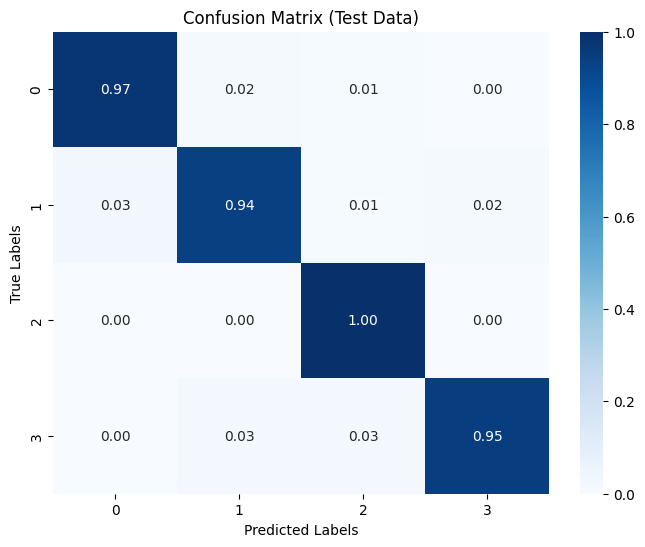

In [18]:
evaluate_model(cv_model, X_test, y_test, label="Test")


[== Evaluation on External Test Data ==]
External Test Loss: 1.1480
External Test Accuracy: 0.7304

Classification Report (External Test Data):
              precision    recall  f1-score   support

           0       0.47      0.76      0.58      1008
           1       0.23      0.98      0.38       229
           2       0.26      0.97      0.40       456
           3       1.00      0.71      0.83      9141

    accuracy                           0.73     10834
   macro avg       0.49      0.86      0.55     10834
weighted avg       0.90      0.73      0.78     10834

External Test AUC: 0.9483


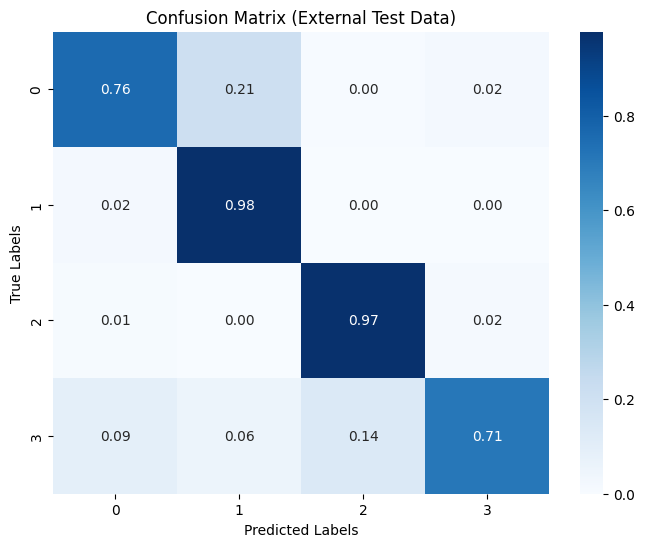

In [19]:
evaluate_model(cv_model, X_test_external, y_test_external, label="External Test")

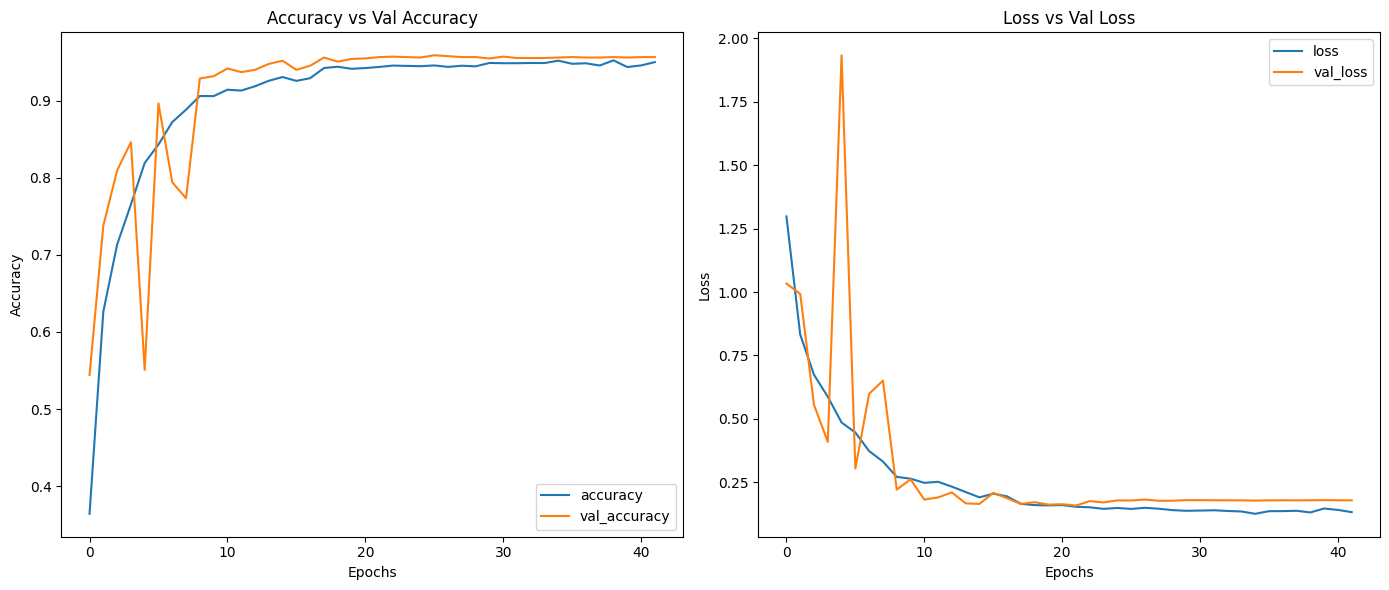

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].plot(history.history['accuracy'], label='accuracy')
ax[0].plot(history.history['val_accuracy'], label='val_accuracy')
ax[0].set_title('Accuracy vs Val Accuracy')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

ax[1].plot(history.history['loss'], label='loss')
ax[1].plot(history.history['val_loss'], label='val_loss')
ax[1].set_title('Loss vs Val Loss')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.tight_layout()
plt.show()